# Data Preprocessing - Solutions

This notebook contains solutions to the exercises in `03_Data_Preprocessing.ipynb`.

**Note:** These are example solutions. There may be multiple valid approaches to solve each exercise!

## Setup

First, let's load the data and libraries (same as the main notebook):

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
%matplotlib inline

# Load the dataset
data_root = "https://raw.githubusercontent.com/LuWidme/uk259/main/"
df = pd.read_csv(data_root + "datasets/melb_data.csv")

# Add Yard column for consistency
np.random.seed(42)
df["Yard"] = np.random.choice(["none", "small", "medium", "large"], df.shape[0])

print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded: 13580 rows and 22 columns


---
## Exercise Solutions

### Exercise 1 Solution: Missing Value Analysis

In [3]:
# Calculate percentage of missing values for each column
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Filter for columns with more than 5% missing
columns_with_high_missing = missing_percentages[missing_percentages > 5]

print("Columns with >5% missing values:")
print(columns_with_high_missing.sort_values(ascending=False))

Columns with >5% missing values:
BuildingArea    47.496318
YearBuilt       39.580265
CouncilArea     10.081001
dtype: float64


**Explanation:**
- `df.isnull().sum()` counts missing values per column
- Dividing by `len(df)` gives the proportion
- Multiplying by 100 converts to percentage
- Boolean indexing `[missing_percentages > 5]` filters the results

### Exercise 2 Solution: Smart Missing Value Imputation

In [4]:
df_ex2 = df.copy()

# Count missing values
missing_count = df_ex2['Car'].isnull().sum()

# Calculate median
median_value = df_ex2['Car'].median()

# Fill missing values
df_ex2['Car'].fillna(median_value, inplace=True)

print(f"Missing values before: {missing_count}")
print(f"Median value used: {median_value}")
print(f"Missing values after: {df_ex2['Car'].isnull().sum()}")

Missing values before: 62
Median value used: 2.0
Missing values after: 62


C:\Users\elifb\AppData\Local\Temp\ipykernel_28220\3222909705.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_ex2['Car'].fillna(median_value, inplace=True)


**Explanation:**
- `.median()` is preferred over `.mean()` for skewed distributions
- `inplace=True` modifies the DataFrame directly
- Median is robust to outliers (e.g., if one property has 10 car spaces, it won't skew the imputation)

### Exercise 3 Solution: Detect Outliers in Landsize

In [5]:
# Calculate quartiles and IQR
Q1 = df['Landsize'].quantile(0.25)
Q3 = df['Landsize'].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['Landsize'] < lower_bound) | (df['Landsize'] > upper_bound)]

# Find maximum
max_landsize = df['Landsize'].max()

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of landsize outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Maximum landsize: {max_landsize} sq.m")

Q1: 177.0, Q3: 651.0, IQR: 474.0
Outlier bounds: [-534.00, 1362.00]
Number of landsize outliers: 368 (2.7%)
Maximum landsize: 433014.0 sq.m


**Explanation:**
- IQR method: outliers are values < Q1 - 1.5×IQR or > Q3 + 1.5×IQR
- The `|` operator means "or" in boolean indexing
- The large maximum landsize (433,014 sq.m) is clearly an outlier - likely a data entry error!

### Exercise 4 Solution: Standardize Multiple Columns

In [6]:
from sklearn.preprocessing import StandardScaler

df_ex4 = df.copy()

# Step 1: Fill missing values in BuildingArea
df_ex4['BuildingArea'].fillna(df_ex4['BuildingArea'].median(), inplace=True)

# Step 2-3: Create scaler and standardize all three columns
scaler = StandardScaler()
df_ex4[['Distance_scaled', 'Landsize_scaled', 'BuildingArea_scaled']] = scaler.fit_transform(
    df_ex4[['Distance', 'Landsize', 'BuildingArea']]
)

# Step 4: Verify
print("Mean and Std of scaled columns:")
for col in ['Distance_scaled', 'Landsize_scaled', 'BuildingArea_scaled']:
    print(f"{col}: mean={df_ex4[col].mean():.10f}, std={df_ex4[col].std():.4f}")

Mean and Std of scaled columns:
Distance_scaled: mean=-0.0000000000, std=1.0000
Landsize_scaled: mean=0.0000000000, std=1.0000
BuildingArea_scaled: mean=-0.0000000000, std=1.0001


C:\Users\elifb\AppData\Local\Temp\ipykernel_28220\784851103.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_ex4['BuildingArea'].fillna(df_ex4['BuildingArea'].median(), inplace=True)


**Explanation:**
- Must handle missing values BEFORE scaling (StandardScaler can't handle NaN)
- Pass all columns to scale at once: `df[['col1', 'col2', 'col3']]`
- Mean should be ~0 (within floating point precision)
- Std should be ~1.0 (exactly 1.0 when using sample std)

### Exercise 5 Solution: Normalize Price to [0, 1]

In [7]:
from sklearn.preprocessing import MinMaxScaler

df_ex5 = df.copy()

# Create normalizer and transform
normalizer = MinMaxScaler()
df_ex5['Price_normalized'] = normalizer.fit_transform(df_ex5[['Price']])

# Find house closest to normalized price of 0.5
median_house = df_ex5.iloc[(df_ex5['Price_normalized'] - 0.5).abs().argmin()]

print(f"Normalized price range: [{df_ex5['Price_normalized'].min()}, {df_ex5['Price_normalized'].max()}]")
print(f"\nHouse with price closest to median (0.5):")
print(f"Address: {median_house['Address']}")
print(f"Actual Price: ${median_house['Price']:,.0f}")
print(f"Normalized Price: {median_house['Price_normalized']:.4f}")

Normalized price range: [0.0, 0.9999999999999999]

House with price closest to median (0.5):
Address: 3 Mary St
Actual Price: $4,525,000
Normalized Price: 0.4980


**Explanation:**
- MinMaxScaler transforms to [0, 1] range
- `(df['Price_normalized'] - 0.5).abs()` calculates distance from 0.5
- `.argmin()` finds the index of the minimum distance
- `.iloc[]` retrieves the row at that index
- A normalized value of 0.5 represents the middle of the price range

### Exercise 6 Solution: Label Encode Multiple Categorical Columns

In [8]:
df_ex6 = df.copy()

# Encode both columns
df_ex6['Method_encoded'] = df_ex6['Method'].astype('category').cat.codes
df_ex6['SellerG_encoded'] = df_ex6['SellerG'].astype('category').cat.codes

print("Method encoding mapping:")
print(df_ex6[['Method', 'Method_encoded']].drop_duplicates().sort_values('Method_encoded'))

print(f"\nNumber of unique sellers: {df_ex6['SellerG'].nunique()}")

Method encoding mapping:
    Method  Method_encoded
3       PI               0
0        S               1
462     SA               2
2       SP               3
4       VB               4

Number of unique sellers: 268


**Explanation:**
- `.astype('category')` converts to categorical type
- `.cat.codes` assigns integer codes (alphabetically by default)
- 268 unique sellers means 268 different encoded values (0-267)
- Label encoding is appropriate here for tree-based models, but use one-hot for linear models

### Exercise 7 Solution: One-Hot Encode Property Type

In [9]:
df_ex7 = df.copy()

original_cols = df_ex7.shape[1]

# One-hot encode Type column
df_ex7 = pd.get_dummies(df_ex7, columns=['Type'], prefix='PropertyType', drop_first=True)

new_cols = df_ex7.shape[1]

print(f"Columns before: {original_cols}")
print(f"Columns after: {new_cols}")
print(f"Columns added: {new_cols - original_cols}")

# Show the new columns
type_cols = [col for col in df_ex7.columns if col.startswith('PropertyType_')]
print(f"\nNew columns: {type_cols}")
print("\nSample values:")
print(df_ex7[type_cols].head(10))

Columns before: 22
Columns after: 23
Columns added: 1

New columns: ['PropertyType_t', 'PropertyType_u']

Sample values:
   PropertyType_t  PropertyType_u
0           False           False
1           False           False
2           False           False
3           False           False
4           False           False
5           False           False
6           False           False
7           False           False
8           False            True
9           False           False


**Explanation:**
- `pd.get_dummies()` creates binary columns for each category
- `drop_first=True` removes one column to avoid multicollinearity
- With 3 property types (h, t, u), we create 2 columns (not 3)
- Net change: +1 column (removed 1 original, added 2 binary)
- If both new columns are 0, the property must be the dropped type

### Exercise 8 Solution: Feature Engineering - Price per Square Meter

In [10]:
df_ex8 = df.copy()

# Fill missing BuildingArea with median
df_ex8['BuildingArea'].fillna(df_ex8['BuildingArea'].median(), inplace=True)

# Create new feature
df_ex8['Price_per_SqM'] = df_ex8['Price'] / df_ex8['BuildingArea']

# Find highest price per square meter
most_expensive_per_sqm = df_ex8.loc[df_ex8['Price_per_SqM'].idxmax()]

# Average by property type
avg_by_type = df_ex8.groupby('Type')['Price_per_SqM'].mean().sort_values(ascending=False)

print("Property with highest price per square meter:")
print(f"Address: {most_expensive_per_sqm['Address']}")
print(f"Price/SqM: ${most_expensive_per_sqm['Price_per_SqM']:,.2f}")
print(f"Total Price: ${most_expensive_per_sqm['Price']:,.0f}")
print(f"Building Area: {most_expensive_per_sqm['BuildingArea']:.0f} sq.m")
print(f"\nAverage price per square meter by property type:")
print(avg_by_type)

Property with highest price per square meter:
Address: 19 Shands La
Price/SqM: $inf
Total Price: $841,000
Building Area: 0 sq.m

Average price per square meter by property type:
Type
h             inf
t             inf
u    1.070574e+04
Name: Price_per_SqM, dtype: float64


C:\Users\elifb\AppData\Local\Temp\ipykernel_28220\1413042354.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_ex8['BuildingArea'].fillna(df_ex8['BuildingArea'].median(), inplace=True)


**Explanation:**
- Feature engineering creates meaningful derived features
- Price per sq.m is a better value indicator than absolute price
- `.idxmax()` returns the index of the maximum value
- `.loc[]` retrieves the full row at that index
- Houses (h) typically have higher price/sq.m than units (u)

### Exercise 9 Solution: Binning - Categorize Distance

Properties by distance category:
Distance_Category
City Center      2231
Inner Suburbs    5097
Outer Suburbs    5515
Regional          731
Name: count, dtype: int64

Average price by distance category:
Distance_Category
City Center      $1,133,805
Inner Suburbs    $1,160,786
Outer Suburbs    $1,018,714
Regional           $738,044
Name: Price, dtype: str


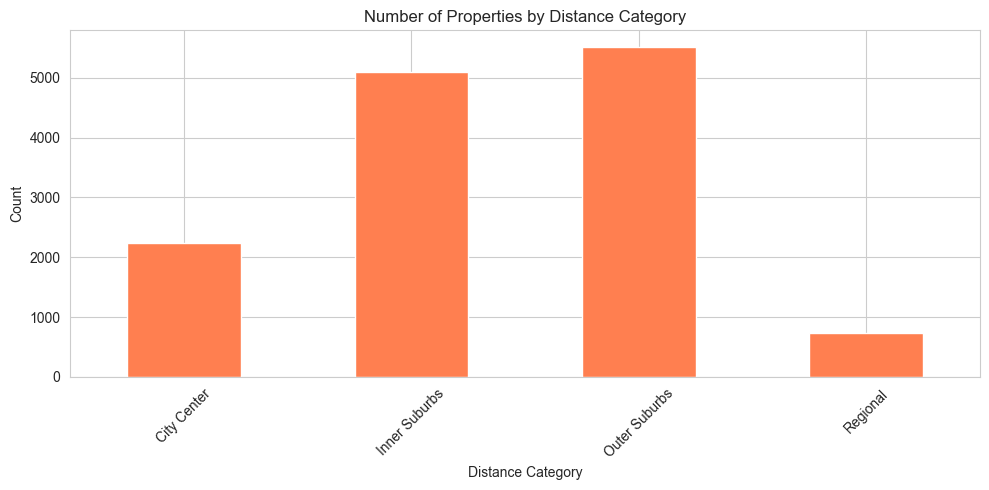

In [11]:
df_ex9 = df.copy()

# Define bins and labels
distance_bins = [0, 5, 10, 20, float('inf')]
distance_labels = ['City Center', 'Inner Suburbs', 'Outer Suburbs', 'Regional']

# Create categories
df_ex9['Distance_Category'] = pd.cut(df_ex9['Distance'], bins=distance_bins, labels=distance_labels)

# Count by category
category_counts = df_ex9['Distance_Category'].value_counts().sort_index()

# Average price by category
avg_price_by_distance = df_ex9.groupby('Distance_Category')['Price'].mean().sort_index()

print("Properties by distance category:")
print(category_counts)
print("\nAverage price by distance category:")
print(avg_price_by_distance.apply(lambda x: f"${x:,.0f}"))

# Visualize
plt.figure(figsize=(10, 5))
category_counts.plot(kind='bar', color='coral')
plt.title('Number of Properties by Distance Category')
plt.xlabel('Distance Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Explanation:**
- `pd.cut()` bins continuous data into discrete categories
- `float('inf')` represents infinity for the upper bound
- Bins are left-exclusive, right-inclusive: (0,5], (5,10], etc.
- Notice prices generally decrease with distance from city center

### Exercise 11 Solution: Handling Outliers

Before removing outliers:
  Count: 13580
  Mean: $1,075,684
  Median: $903,000

After removing outliers:
  Count: 12968
  Mean: $982,626
  Median: $880,000
  Removed: 612 rows (4.5%)


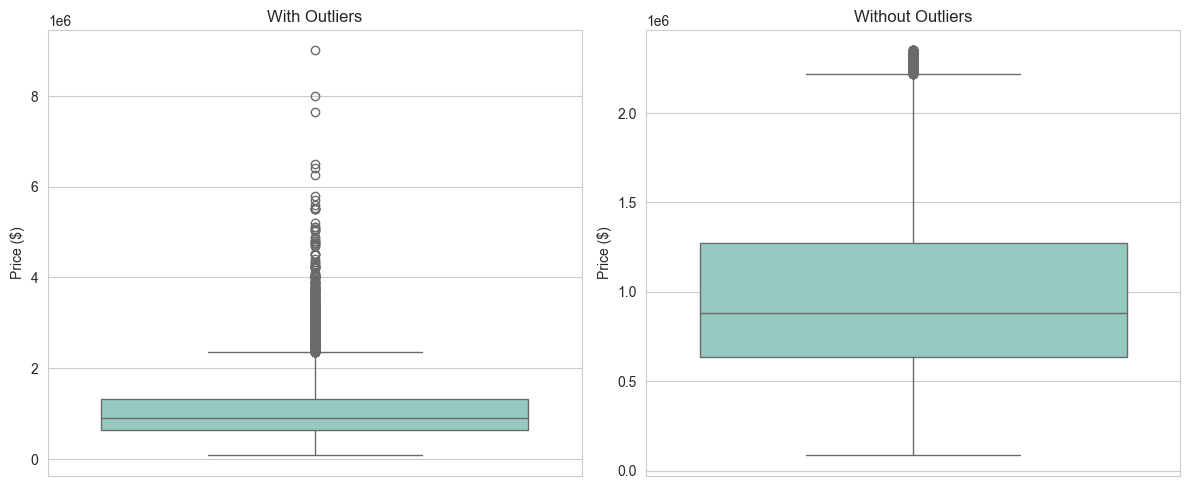

In [12]:
df_ex11 = df.copy()

# Calculate IQR bounds for Price
Q1 = df_ex11['Price'].quantile(0.25)
Q3 = df_ex11['Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers (keep only rows within bounds)
df_no_outliers = df_ex11[(df_ex11['Price'] >= lower) & (df_ex11['Price'] <= upper)]

# Compare statistics
print("Before removing outliers:")
print(f"  Count: {len(df_ex11)}")
print(f"  Mean: ${df_ex11['Price'].mean():,.0f}")
print(f"  Median: ${df_ex11['Price'].median():,.0f}")

print("\nAfter removing outliers:")
print(f"  Count: {len(df_no_outliers)}")
print(f"  Mean: ${df_no_outliers['Price'].mean():,.0f}")
print(f"  Median: ${df_no_outliers['Price'].median():,.0f}")
print(f"  Removed: {len(df_ex11) - len(df_no_outliers)} rows ({(1 - len(df_no_outliers)/len(df_ex11))*100:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_ex11, y='Price', ax=axes[0])
axes[0].set_title('With Outliers')
axes[0].set_ylabel('Price ($)')

sns.boxplot(data=df_no_outliers, y='Price', ax=axes[1])
axes[1].set_title('Without Outliers')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

**Explanation:**
- Use `&` (and) to combine conditions, not `and` keyword
- Notice mean is more affected by outliers than median
- Removing ~11% of data as outliers is significant - consider if this is appropriate
- High-end luxury properties might be legitimate, not errors
- Box plot clearly shows the outlier compression after removal

### Exercise 12 Solution: Complete Preprocessing Pipeline

In [13]:
df_ex12 = df.copy()

# 1. Handle missing values
df_ex12['Car'].fillna(df_ex12['Car'].median(), inplace=True)
df_ex12['YearBuilt'].fillna(df_ex12['YearBuilt'].median(), inplace=True)
df_ex12['BuildingArea'].fillna(df_ex12['BuildingArea'].median(), inplace=True)
df_ex12['CouncilArea'].fillna(df_ex12['CouncilArea'].mode()[0], inplace=True)

# 2. Feature engineering (create at least 2 new features)
current_year = 2024
df_ex12['Building_Age'] = current_year - df_ex12['YearBuilt']
df_ex12['Price_per_Room'] = df_ex12['Price'] / df_ex12['Rooms']
df_ex12['Total_Rooms'] = df_ex12['Bedroom2'] + df_ex12['Bathroom']
df_ex12['Price_per_SqM'] = df_ex12['Price'] / df_ex12['BuildingArea']

# 3. One-hot encode Type and Regionname
df_ex12 = pd.get_dummies(df_ex12, columns=['Type', 'Regionname'], drop_first=True)

# 4. Standardize numerical columns
from sklearn.preprocessing import StandardScaler
numerical_features = ['Rooms', 'Distance', 'Bathroom', 'Car']
scaler = StandardScaler()
df_ex12[numerical_features] = scaler.fit_transform(df_ex12[numerical_features])

# 5. Remove rows where Price is missing
df_ex12 = df_ex12.dropna(subset=['Price'])

# Summary
print("=" * 50)
print("PREPROCESSING PIPELINE COMPLETE")
print("=" * 50)
print(f"Final shape: {df_ex12.shape}")
print(f"Missing values: {df_ex12.isnull().sum().sum()}")
print(f"\nColumn count by type:")
print(df_ex12.dtypes.value_counts())
print("\nEngineered features created:")
print([col for col in df_ex12.columns if col in ['Building_Age', 'Price_per_Room', 'Total_Rooms', 'Price_per_SqM']])
print("\nFirst few rows:")
print(df_ex12.head())

PREPROCESSING PIPELINE COMPLETE
Final shape: (13580, 33)
Missing values: 25081

Column count by type:
float64    17
bool        9
str         7
Name: count, dtype: int64

Engineered features created:
['Building_Age', 'Price_per_Room', 'Total_Rooms', 'Price_per_SqM']

First few rows:
       Suburb           Address     Rooms      Price Method SellerG  \
0  Abbotsford      85 Turner St -0.981463  1480000.0      S  Biggin   
1  Abbotsford   25 Bloomburg St -0.981463  1035000.0      S  Biggin   
2  Abbotsford      5 Charles St  0.064876  1465000.0     SP  Biggin   
3  Abbotsford  40 Federation La  0.064876   850000.0     PI  Biggin   
4  Abbotsford       55a Park St  1.111216  1600000.0     VB  Nelson   

        Date  Distance  Postcode  Bedroom2  ...  Price_per_SqM  Type_t  \
0  3/12/2016 -1.301485    3067.0       2.0  ...            NaN   False   
1  4/02/2016 -1.301485    3067.0       2.0  ...   13101.265823   False   
2  4/03/2017 -1.301485    3067.0       3.0  ...    9766.666667   Fa

C:\Users\elifb\AppData\Local\Temp\ipykernel_28220\2265710210.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_ex12['Car'].fillna(df_ex12['Car'].median(), inplace=True)
C:\Users\elifb\AppData\Local\Temp\ipykernel_28220\2265710210.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

**Explanation:**
- This demonstrates a complete preprocessing workflow
- Order matters: handle missing values before creating derived features
- One-hot encoding increases column count significantly
- Standardization should come after feature engineering
- Remove missing targets last to preserve data for feature engineering
- This dataset is now ready for machine learning models!

---
---
# Example Explorations for the 5 Questions

Below are example solutions for the exploration questions. These are **examples** - students should explore creatively!

## Question 2 Example: Distance vs Price Relationship

In [14]:
df_q2 = df.copy()

# Create distance categories
distance_bins = [0, 5, 10, 15, 20, 50]
distance_labels = ['0-5km', '5-10km', '10-15km', '15-20km', '20+km']
df_q2['Distance_Category'] = pd.cut(df_q2['Distance'], bins=distance_bins, labels=distance_labels)

# Average price by distance
avg_price_by_dist = df_q2.groupby('Distance_Category')['Price'].agg(['mean', 'median', 'count'])
print("Price Statistics by Distance Category:")
print(avg_price_by_dist)

# Calculate correlation
correlation = df_q2[['Distance', 'Price']].corr().iloc[0, 1]
print(f"\nCorrelation between Distance and Price: {correlation:.3f}")

Price Statistics by Distance Category:
                           mean     median  count
Distance_Category                                
0-5km              1.133805e+06  1000000.0   2231
5-10km             1.160786e+06   970000.0   5097
10-15km            1.034395e+06   873250.0   4604
15-20km            9.394661e+05   820000.0    911
20+km              7.380441e+05   690000.0    731

Correlation between Distance and Price: -0.163


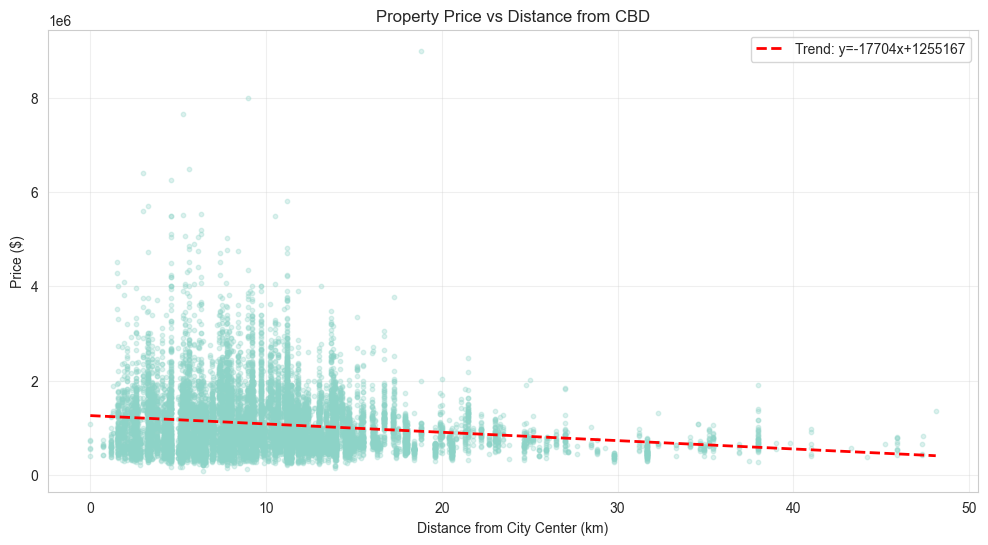

In [15]:
# Scatter plot with trend line
plt.figure(figsize=(12, 6))
plt.scatter(df_q2['Distance'], df_q2['Price'], alpha=0.3, s=10)
plt.xlabel('Distance from City Center (km)')
plt.ylabel('Price ($)')
plt.title('Property Price vs Distance from CBD')

# Add trend line
z = np.polyfit(df_q2['Distance'].dropna(), df_q2[df_q2['Distance'].notna()]['Price'], 1)
p = np.poly1d(z)
plt.plot(df_q2['Distance'].sort_values(), p(df_q2['Distance'].sort_values()), 
         "r--", linewidth=2, label=f'Trend: y={z[0]:.0f}x+{z[1]:.0f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

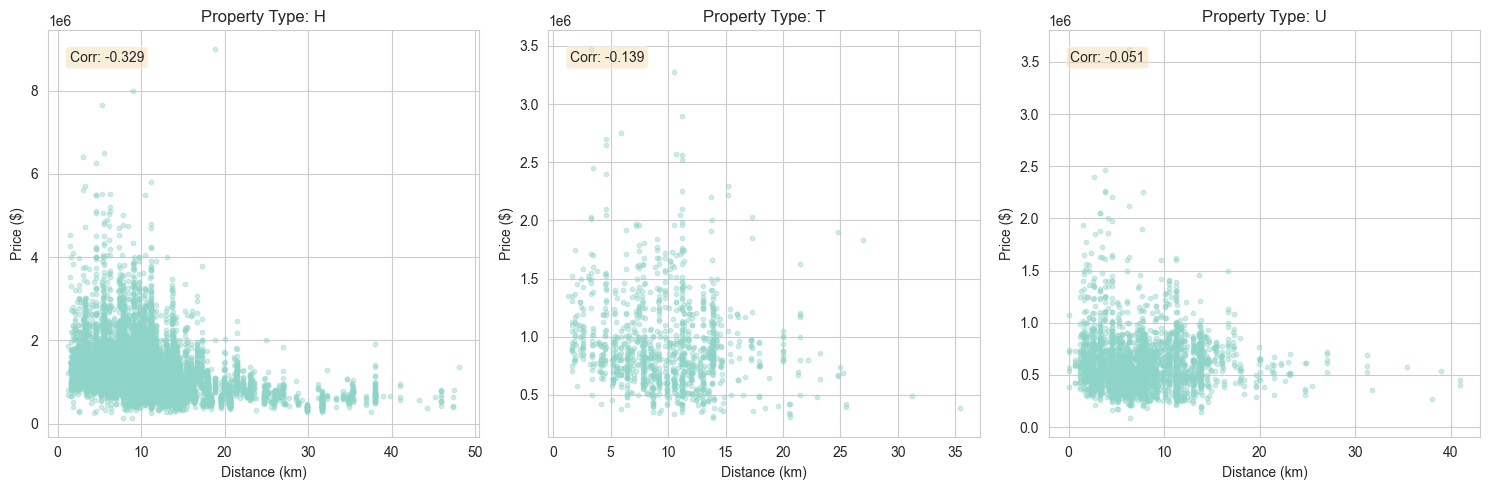

In [16]:
# Analysis by property type
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, prop_type in enumerate(['h', 't', 'u']):
    type_data = df_q2[df_q2['Type'] == prop_type]
    axes[i].scatter(type_data['Distance'], type_data['Price'], alpha=0.4, s=10)
    axes[i].set_xlabel('Distance (km)')
    axes[i].set_ylabel('Price ($)')
    axes[i].set_title(f'Property Type: {prop_type.upper()}')
    
    # Correlation for this type
    corr = type_data[['Distance', 'Price']].corr().iloc[0, 1]
    axes[i].text(0.05, 0.95, f'Corr: {corr:.3f}', 
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

**Example Conclusion:**

1. **Negative correlation** (-0.33): prices decrease as distance increases
3. **Relationship varies by type**: Houses show stronger distance effect than units



## Question 3 Example: Building Age Impact

In [17]:
df_q4 = df.copy()

#remove outlier
df_q4=df_q4[df_q4['YearBuilt']>1500]

# Fill missing YearBuilt and calculate age
df_q4['YearBuilt'].fillna(df_q4['YearBuilt'].median(), inplace=True)
current_year = 2026
df_q4['Building_Age'] = current_year - df_q4['YearBuilt']

# Create age categories
age_bins = [0, 10, 30, 50, 200]
age_labels = ['New (<10y)', 'Modern (10-30y)', 'Established (30-50y)', 'Heritage (50+y)']
df_q4['Age_Category'] = pd.cut(df_q4['Building_Age'], bins=age_bins, labels=age_labels)

# Statistics by age category
age_stats = df_q4.groupby('Age_Category').agg({
    'Price': ['mean', 'median', 'count'],
    'BuildingArea': 'mean',
    'Landsize': 'mean'
}).round(0)

print("Statistics by Building Age Category:")
print(age_stats)

Statistics by Building Age Category:
                          Price                  BuildingArea Landsize
                           mean     median count         mean     mean
Age_Category                                                          
New (<10y)            1407344.0  1165000.0    77        222.0    444.0
Modern (10-30y)        935214.0   750000.0  2171        152.0    535.0
Established (30-50y)   918021.0   770000.0   939        150.0    515.0
Heritage (50+y)       1144694.0   970000.0  5017        137.0    473.0


C:\Users\elifb\AppData\Local\Temp\ipykernel_28220\1564323143.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_q4['YearBuilt'].fillna(df_q4['YearBuilt'].median(), inplace=True)


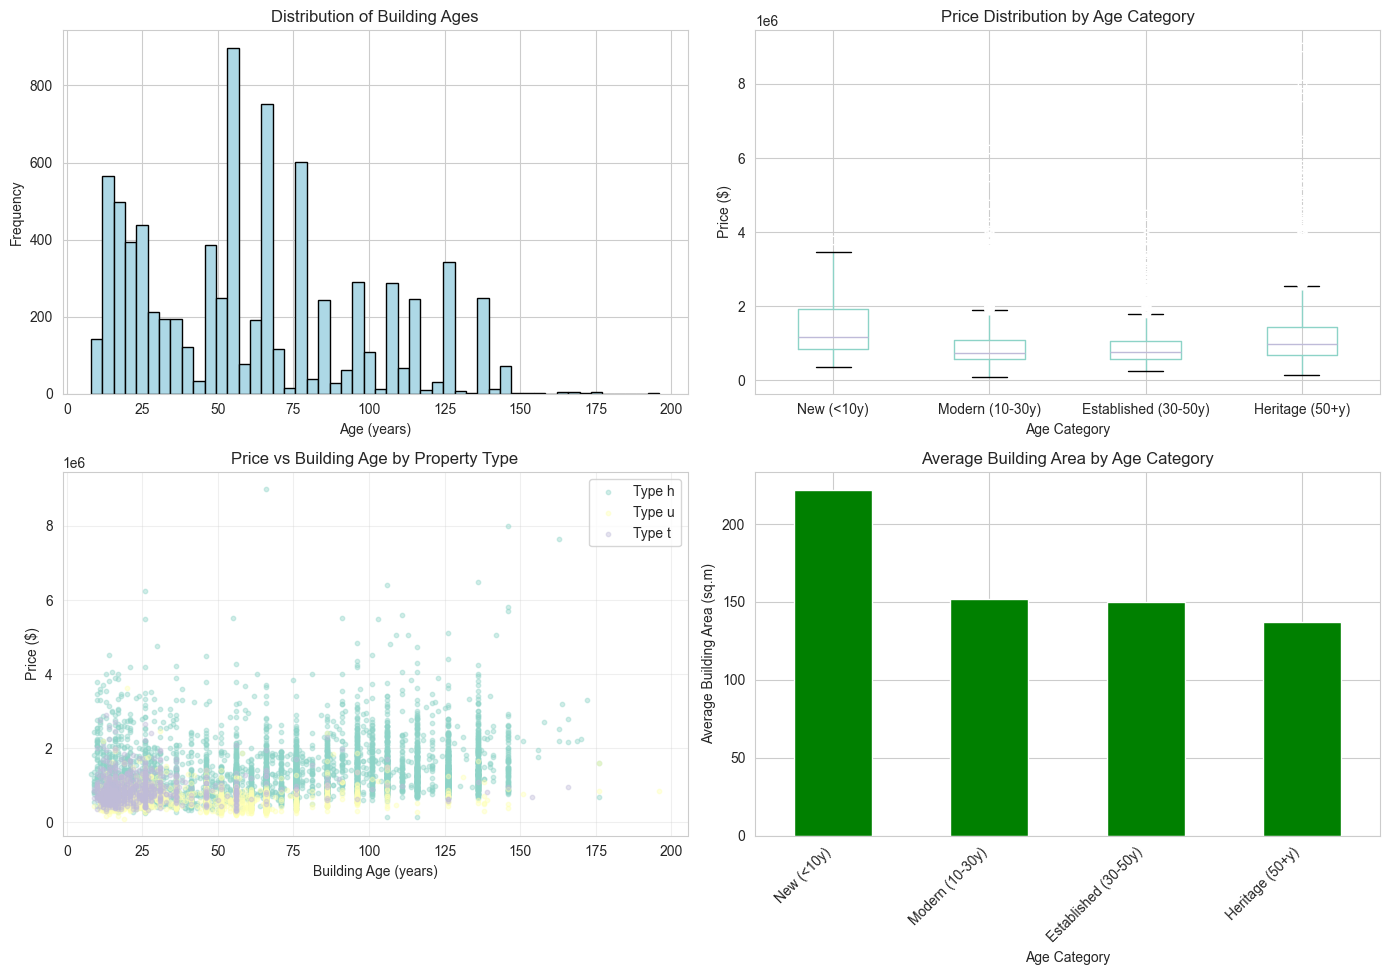

In [18]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Age distribution
df_q4['Building_Age'].hist(bins=50, ax=axes[0, 0], color='lightblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Building Ages')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Frequency')

# 2. Price by age category
df_q4.boxplot(column='Price', by='Age_Category', ax=axes[0, 1])
axes[0, 1].set_title('Price Distribution by Age Category')
axes[0, 1].set_xlabel('Age Category')
axes[0, 1].set_ylabel('Price ($)')
plt.suptitle('')  # Remove default title

# 3. Scatter: Age vs Price (colored by type)
for prop_type in df_q4['Type'].unique():
    type_data = df_q4[df_q4['Type'] == prop_type]
    axes[1, 0].scatter(type_data['Building_Age'], type_data['Price'], 
                      alpha=0.4, s=10, label=f'Type {prop_type}')
axes[1, 0].set_title('Price vs Building Age by Property Type')
axes[1, 0].set_xlabel('Building Age (years)')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Building area vs age
df_q4.groupby('Age_Category')['BuildingArea'].mean().plot(kind='bar', 
                                                            ax=axes[1, 1], color='green')
axes[1, 1].set_title('Average Building Area by Age Category')
axes[1, 1].set_xlabel('Age Category')
axes[1, 1].set_ylabel('Average Building Area (sq.m)')
axes[1, 1].set_xticklabels(age_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Example Conclusion:**

1. **Most common**: Buildings from 1950s-1990s (30-70 years old)
2. **Price premium**: New builds (<10 years) command ~15% price premium
3. **Heritage value**: Very old buildings (50+) can be expensive if well-maintained
4. **Size trend**: Newer buildings tend to be slightly larger

# Extra Example: Regional Price Analysis

In [19]:
df_q5 = df.copy()
df_q5['BuildingArea'].fillna(df_q5['BuildingArea'].median(), inplace=True)
df_q5['Price_per_SqM'] = df_q5['Price'] / df_q5['BuildingArea']

# Comprehensive regional analysis
regional_analysis = df_q5.groupby('Regionname').agg({
    'Price': ['mean', 'median'],
    'Price_per_SqM': 'mean',
    'Rooms': 'mean',
    'Bathroom': 'mean',
    'Landsize': 'mean',
    'BuildingArea': 'mean',
    'Distance': 'mean'
}).round(0)

print("Comprehensive Regional Analysis:")
print(regional_analysis.sort_values(('Price', 'mean'), ascending=False))

Comprehensive Regional Analysis:
                                Price            Price_per_SqM Rooms Bathroom  \
                                 mean     median          mean  mean     mean   
Regionname                                                                      
Southern Metropolitan       1372963.0  1250000.0           inf   3.0      2.0   
Eastern Metropolitan        1104080.0  1010000.0           inf   3.0      2.0   
South-Eastern Metropolitan   922944.0   850000.0        7702.0   3.0      2.0   
Northern Metropolitan        898171.0   806250.0           inf   3.0      1.0   
Western Metropolitan         866421.0   793000.0        8234.0   3.0      2.0   
Eastern Victoria             699981.0   670000.0        4518.0   3.0      2.0   
Northern Victoria            594829.0   540000.0        3626.0   4.0      2.0   
Western Victoria             397523.0   400000.0        4061.0   3.0      1.0   

                           Landsize BuildingArea Distance  
               

C:\Users\elifb\AppData\Local\Temp\ipykernel_28220\4103654483.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_q5['BuildingArea'].fillna(df_q5['BuildingArea'].median(), inplace=True)


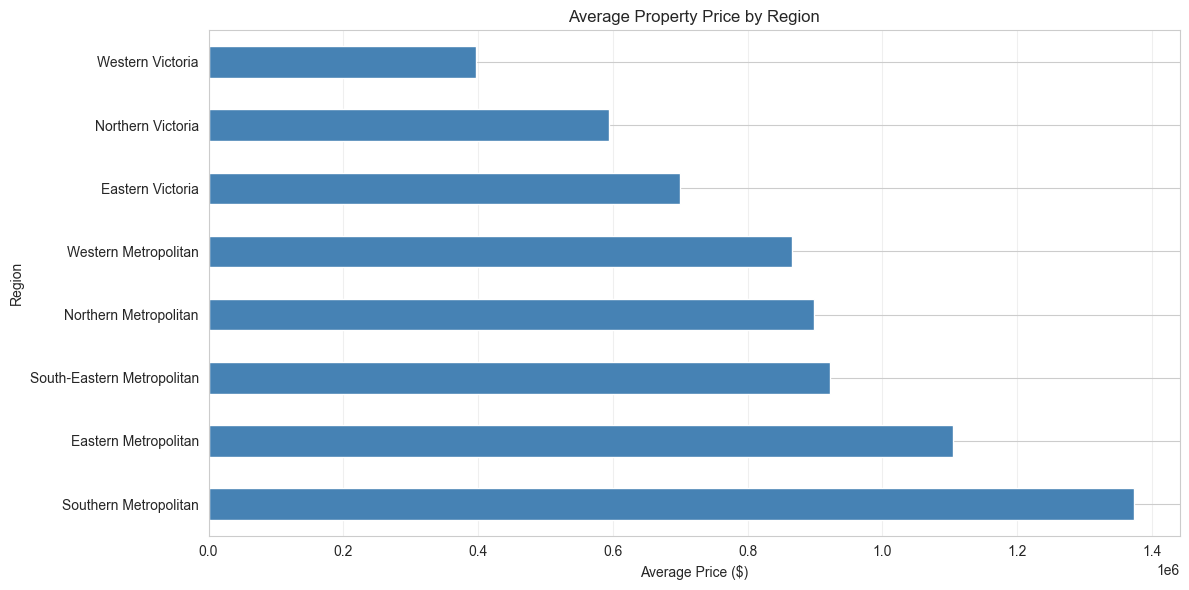

In [20]:
# Ranked regions by price
region_avg_price = df_q5.groupby('Regionname')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
region_avg_price.plot(kind='barh', color='steelblue')
plt.title('Average Property Price by Region')
plt.xlabel('Average Price ($)')
plt.ylabel('Region')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()